<a href="https://colab.research.google.com/github/suyz1213/cs666student/blob/main/CS666_Assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

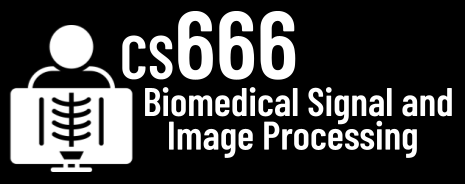
#Assignment 6

In [ ]:
# NAME: Yaozong Su

In [ ]:
# In this assignment, we will visualize and explore a CT scan!

In [1]:
# load numpy and matplotlib
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [2]:
# we are using pydicom, so lets install it!
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 2.4 MB/s eta 0:00:00


**Task 1**: Download and visualize data with SliceDrop! [20 Points]

In [ ]:
# Use wget to download https://cs666.org/data/ct.zip!
# This is a CT scan of an arm in DICOM format.

In [3]:
!wget https://cs666.org/data/ct.zip

--2026-05-06 17:01:15--  https://cs666.org/data/ct.zip
Resolving cs666.org (cs666.org)... 185.199.110.153, 185.199.111.153, 185.199.108.153, ...
Connecting to cs666.org (cs666.org)|185.199.110.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5847706 (5.6M) [application/x-zip-compressed]
Saving to: ‘ct.zip’

ct.zip              100%[===================>]   5.58M  23.5MB/s    in 0.2s    

2026-05-06 17:01:16 (23.5 MB/s) - ‘ct.zip’ saved [5847706/5847706]



In [ ]:
# Then use the following snippet to extract the data.

In [4]:
import zipfile
with zipfile.ZipFile('ct.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

In [ ]:
# 1) Let's explore the data using the Files panel on the left.
# TODO: 220

In [ ]:
# 2) Let's visualize the data with SliceDrop!
# Go to https://slicedrop.com and drag'n'drop all .dcm files into the browser.
# Please use the 2D sliders to show axial, sagittal, and coronal slices in 3D.

In [ ]:
# TODO Please post a screenshot of SliceDrop's 3D View in the text box below by
# using the Upload image button after double-click. This should not be volume
# rendering but show the 3 cross sections.

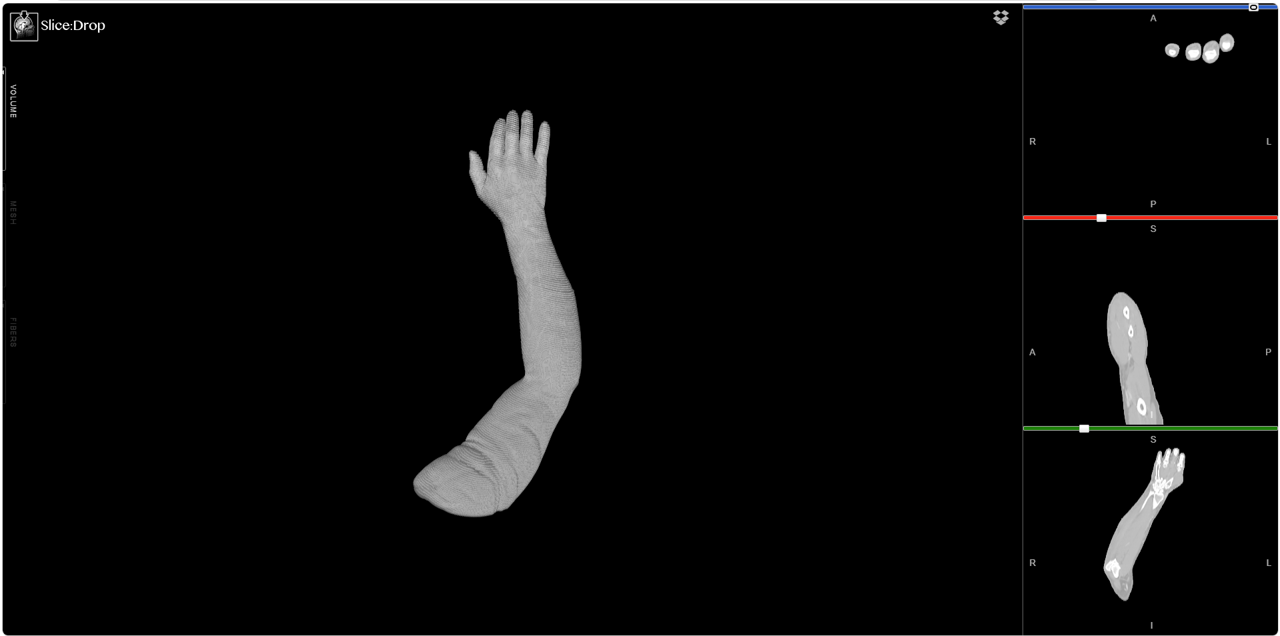

In [ ]:
# 3) Let's visualize only the bones! Please use the thresholding
# based on a window suitable for bones and show a 3D volume rendering.

In [ ]:
# TODO Please post a screenshot of SliceDrop's 3D View in the text box below by
# using the Upload image button after double-click.

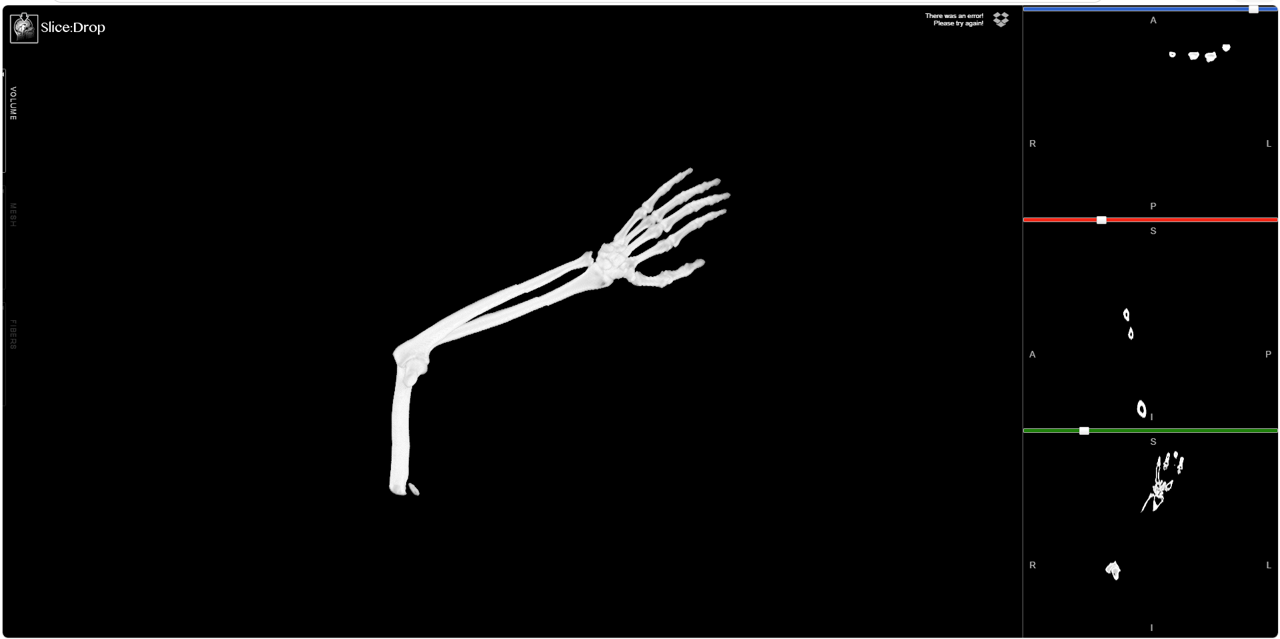

**Task 2**: Load the data using pydicom as a 3D volume and then reslice it! [35 Points]

In [ ]:
# 1) Now loop through all the DICOM files and store them in a 3D numpy array.
# Hint: You can either store them in a list first or read the dimensions of a
# single image slice to properly create the 3D numpy array.
# Hint 2: os.listdir(DIR) gives a list of filenames in a directory.
# Hint 2b: This list is not sorted - make sure you sort it.
# Hint 3: The dcmread function loads a single DICOM file.
# Hint 4: You can then use .pixel_array to access the image data.

In [5]:
from pydicom import dcmread

In [6]:
import os

dir_path = "/content/ct"
files = sorted(os.listdir(dir_path))

print("Num of dcm:", len(files))
print("top10:", files[:10])

Num of dcm: 220
top10: ['IM-0001-0001.dcm', 'IM-0001-0002.dcm', 'IM-0001-0003.dcm', 'IM-0001-0004.dcm', 'IM-0001-0005.dcm', 'IM-0001-0006.dcm', 'IM-0001-0007.dcm', 'IM-0001-0008.dcm', 'IM-0001-0009.dcm', 'IM-0001-0010.dcm']


In [7]:
first_path = os.path.join(dir_path, files[0])
ds = dcmread(first_path)

img = ds.pixel_array

print("image shape:", img.shape)
print("dtype:", img.dtype)

image shape: (454, 512)
dtype: uint16


In [8]:
volume = np.zeros((220, 454, 512), dtype=np.uint16)

In [9]:
for i, fname in enumerate(files):
    path = os.path.join(dir_path, fname)
    ds = dcmread(path)

    volume[i, :, :] = ds.pixel_array

In [ ]:
# 2) Now create and show axial, sagittal, and coronal slices from the 3D volume.
# Hint: Please use imshow(XX, cmap='gray') to show the image.

In [10]:
axial_idxs = [
    volume.shape[0] // 4,
    volume.shape[0] // 2,
    3 * volume.shape[0] // 4
]

coronal_idxs = [
    volume.shape[1] // 4,
    volume.shape[1] // 2,
    3 * volume.shape[1] // 4
]

sagittal_idxs = [
    volume.shape[2] // 4,
    volume.shape[2] // 2,
    3 * volume.shape[2] // 4
]

In [ ]:
# TODO: YOUR CODE FOR AXIAL

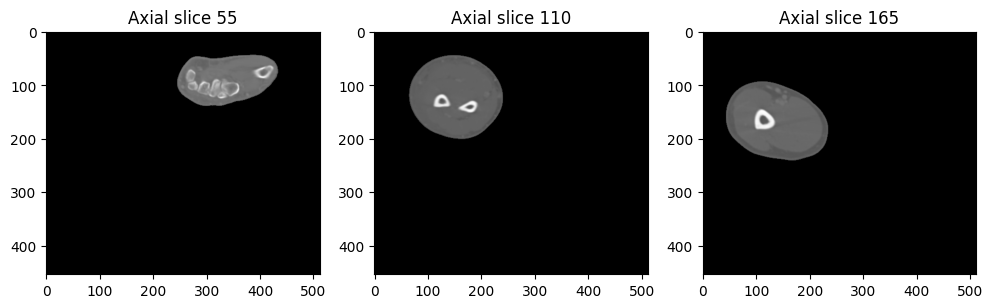

In [12]:
plt.figure(figsize=(12,4))

for i, idx in enumerate(axial_idxs):
    plt.subplot(1,3,i+1)
    plt.imshow(volume[idx, :, :], cmap='gray')
    plt.title(f"Axial slice {idx}")

plt.show()

In [ ]:
# TODO: YOUR CODE FOR SAGITTAL

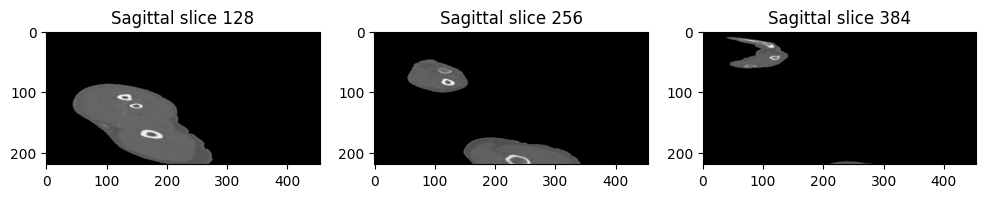

In [13]:
plt.figure(figsize=(12,4))

for i, idx in enumerate(sagittal_idxs):
    plt.subplot(1,3,i+1)
    plt.imshow(volume[:, :, idx], cmap='gray')
    plt.title(f"Sagittal slice {idx}")

plt.show()

In [ ]:
# TODO: YOUR CODE FOR CORONAL

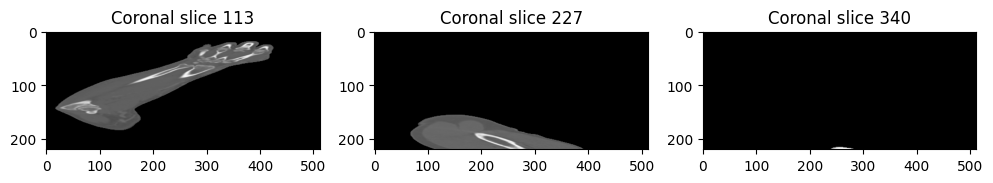

In [14]:
plt.figure(figsize=(12,4))

for i, idx in enumerate(coronal_idxs):
    plt.subplot(1,3,i+1)
    plt.imshow(volume[:, idx, :], cmap='gray')
    plt.title(f"Coronal slice {idx}")

plt.show()

**Task 3**: Use the Window/Level-technique to visualize the data! [45 Points]

In [ ]:
# We will now enhance the visualization from above by performing
# Window/Level adjustment.
# Here is one way of doing that:
#   vmin = level - window/2
#   vmax = level + window/2
#   plt.imshow(hu_pixels + rescale, cmap='gray', vmin=vmin, vmax=vmax)
#   plt.show()

In [ ]:
# 1) Please load the Window/Level values from the DICOM file,
# print these values, and then visualize one slice with window/level adjustment.
# Hint: The DICOM header has the following tags.
#   (0028, 1050) Window Center
#   (0028, 1051) Window Width
# Hint 2: You can use slice[key].value to access DICOM tag values.
# Hint 3: (0028, 1052) Rescale Intercept might be important.

In [15]:
first_path = os.path.join(dir_path, files[200])
ds = dcmread(first_path)

In [16]:
level = ds[(0x0028, 0x1050)].value
window = ds[(0x0028, 0x1051)].value
rescale_intercept = ds[(0x0028, 0x1052)].value

print("Level:", level)
print("Window:", window)
print("Rescale Intercept:", rescale_intercept)

Level: 30
Window: 410
Rescale Intercept: -1024


In [17]:
img = ds.pixel_array
hu_pixels = img + rescale_intercept

In [18]:
vmin = level - window/2
vmax = level + window/2

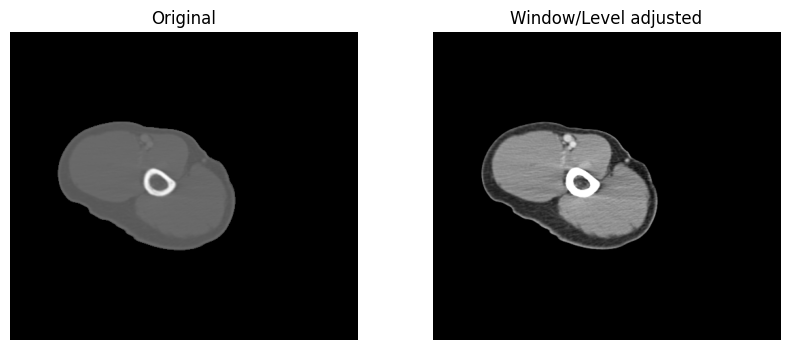

In [19]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(hu_pixels, cmap='gray', vmin=vmin, vmax=vmax)
plt.title("Window/Level adjusted")
plt.axis('off')

plt.show()

In [ ]:
# 2) Play around with different Window/Level values that enhance
# the visualization.

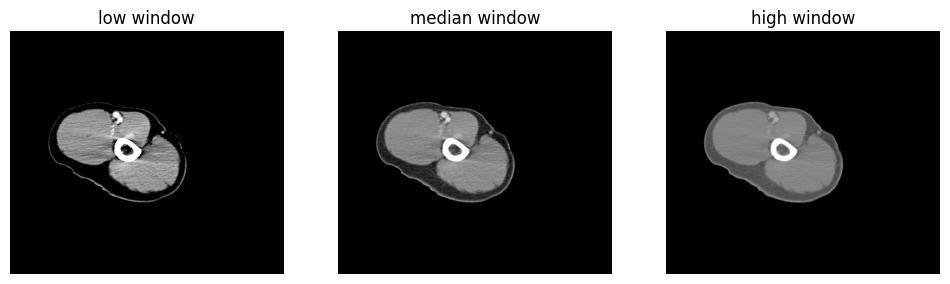

In [20]:
settings = [
    ("low window", 40, 200),
    ("median window", 40, 400),
    ("high window", 40, 800)
]

plt.figure(figsize=(12,4))

for i, (name, level, window) in enumerate(settings):
    vmin = level - window/2
    vmax = level + window/2

    plt.subplot(1,3,i+1)
    plt.imshow(hu_pixels, cmap='gray', vmin=vmin, vmax=vmax)
    plt.title(name)
    plt.axis('off')

plt.show()

In [ ]:
# Which values make sense and why?

#### If level is ~40, low window makes tissue better. Because a smaller window narrows the HU range and increases contrast around the fixed level.


**Bonus**: Create segmentations (label maps) for the volume using thresholding HU! [33 Points]

In [ ]:
# Similar to Window/Level adjustment for visualization, we can threshold
# the volume to highlight the following components using the Hounsfield Units:
# 1) Fat
# 2) Soft Tissue
# 3) Bones
#
# Please create 3 segmentation masks for these structures.
# Then, please visualize each 3 slices per structure to showcase the segmentation.
# Hint: As a reminder, the following code allows thresholding of a numpy array.
#   new_mask = imagevolume.copy()
#   new_mask[new_mask < XXX] = 0
# Hint2: You might need to cast new_mask to int16 not uint16.

In [21]:
idx = [50, 120, 190]

def hu_slice(i):
    ds = dcmread(os.path.join(dir_path, files[i]))
    img = ds.pixel_array
    hu = img + ds.RescaleIntercept
    return hu.astype(np.int16)

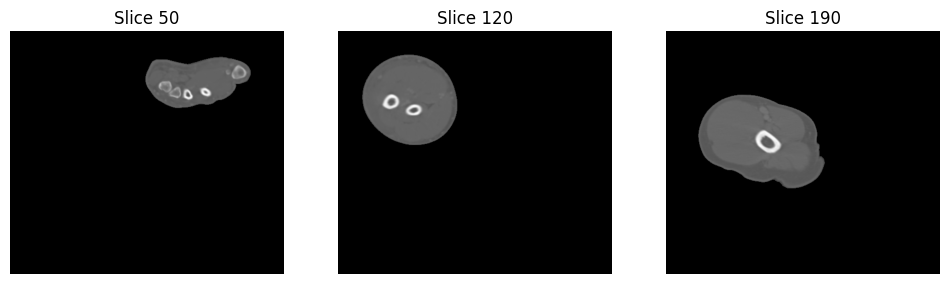

In [22]:
plt.figure(figsize=(12,4))

for k, i in enumerate(idx):
    ds = dcmread(os.path.join(dir_path, files[i]))
    img = ds.pixel_array

    plt.subplot(1,3,k+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Slice {i}")
    plt.axis('off')

plt.show()

In [ ]:
# TODO: YOUR CODE TO SEGMENT FAT

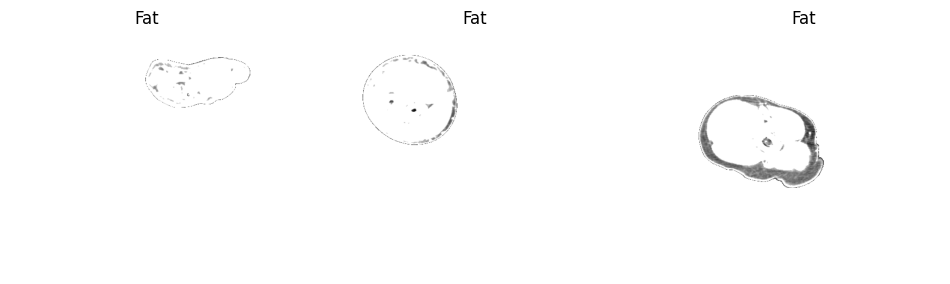

In [23]:
plt.figure(figsize=(12,4))

for k, i in enumerate(idx):
    hu = hu_slice(i)

    mask = hu.copy()
    mask[(mask < -190) | (mask > -30)] = 0

    plt.subplot(1,3,k+1)
    plt.imshow(mask, cmap='gray')
    plt.title("Fat")
    plt.axis('off')

plt.show()

In [ ]:
# TODO: YOUR CODE TO SEGMENT SOFT TISSUE

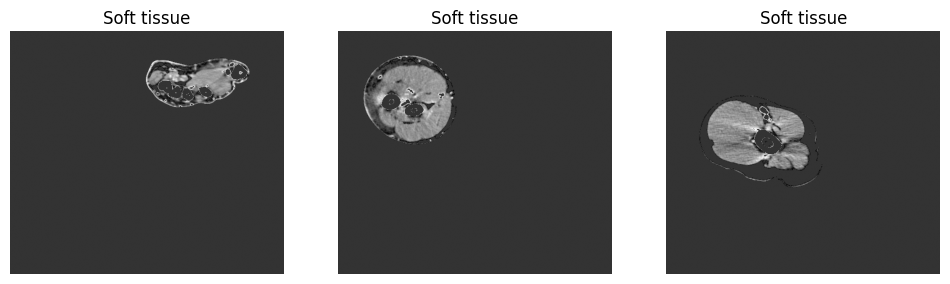

In [24]:
plt.figure(figsize=(12,4))

for k, i in enumerate(idx):
    hu = hu_slice(i)

    mask = hu.copy()
    mask[(mask < -30) | (mask > 120)] = 0

    plt.subplot(1,3,k+1)
    plt.imshow(mask, cmap='gray')
    plt.title("Soft tissue")
    plt.axis('off')

plt.show()

In [ ]:
# TODO: YOUR CODE TO SEGMENT BONES

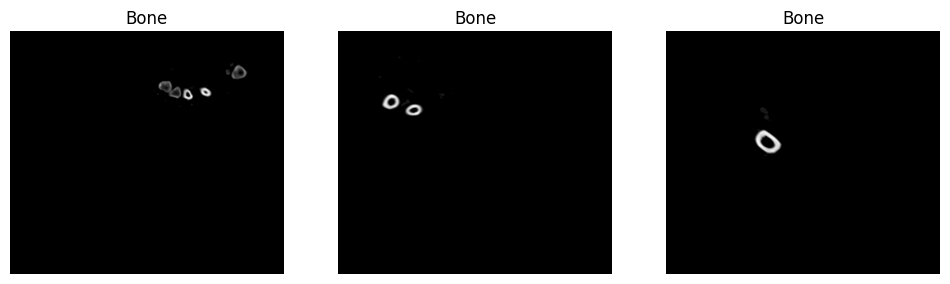

In [25]:
plt.figure(figsize=(12,4))

for k, i in enumerate(idx):
    hu = hu_slice(i)

    mask = hu.copy()
    mask[mask < 120] = 0

    plt.subplot(1,3,k+1)
    plt.imshow(mask, cmap='gray')
    plt.title("Bone")
    plt.axis('off')

plt.show()

In [ ]:
# Are the segmentations good?

#### I think the segmentations are good because we only setted few rough threshold.

In [ ]:
#
# Thank you and Great job!!
#
#                _.---._
#              .'       `.
#              :)       (:
#              \ (@) (@) /
#               \   A   /
#                )     (
#                \"""""/
#                 `._.'
#                  .=.
#          .---._.-.=.-._.---.
#         / ':-(_.-: :-._)-:` \
#        / /' (__.-: :-.__) `\ \
#       / /  (___.-` '-.___)  \ \
#      / /   (___.-'^`-.___)   \ \
#     / /    (___.-'=`-.___)    \ \
#    / /     (____.'=`.____)     \ \
#   / /       (___.'=`.___)       \ \
#  (_.;       `---'.=.`---'       ;._)
#  ;||        __  _.=._  __        ||;
#  ;||       (  `.-.=.-.'  )       ||;
#  ;||       \    `.=.'    /       ||;
#  ;||        \    .=.    /        ||;
#  ;||       .-`.`-._.-'.'-.       ||;
# .:::\      ( ,): O O :(, )      /:::.
# |||| `     / /'`--'--'`\ \     ' ||||
# ''''      / /           \ \      ''''
#          / /             \ \
#         / /               \ \
#        / /                 \ \
#       / /                   \ \
#      / /                     \ \
#     /.'                       `.\
#    (_)'                       `(_)
#     \\.                       .//
#      \\.                     .//
#       \\.                   .//
#        \\.                 .//
#         \\.               .//
#          \\.             .//
#     jgs   \\.           .//
#           ///)         (\\\
#         ,///'           `\\\,
#        ///'               `\\\
#       ""'                   '""